# Exploratory Data Analysis (EDA)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

pd.set_option('display.max_columns', 100)

1) load data and inspect structure

In [5]:
df = pd.read_csv('data.csv')

# Rename the unnamed index-like column to keep references explicit.
first_col = df.columns[0]
if str(first_col).startswith('Unnamed') or first_col == '':
    df = df.rename(columns={first_col: 'row_id'})

print('Shape:', df.shape)
print('Columns:')
print(df.columns.tolist())
df.head()

Shape: (1697, 32)
Columns:
['row_id', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'lastfm_url', 'track', 'artist', 'seeds', 'number_of_emotion_tags', 'valence_tags', 'arousal_tags', 'dominance_tags', 'mbid', 'spotify_id', 'genre']


,row_id,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,lastfm_url,track,artist,seeds,number_of_emotion_tags,valence_tags,arousal_tags,dominance_tags,mbid,spotify_id,genre
0,0,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.147,2,-8.822,1,0.0355,0.857,0.000003,0.0913,0.0765,141.284,3,acoustic,https://www.last.fm/music/a%2bgreat%2bbig%2bwo...,Say Something,A Great Big World,['sad'],7,2.887157,3.535294,4.034216,4a88e54b-3fd9-4d99-9787-ea2853cfbba1,6Vc5wAMmXdKIAM7WUoEb7N,indie pop
1,1,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.414,0,-8.700,1,0.0369,0.294,0.000000,0.1510,0.6690,130.088,4,acoustic,https://www.last.fm/music/jason%2bmraz/_/lucky,Lucky,Jason Mraz,"['romantic', 'sweet']",10,7.779724,4.980663,6.143867,f68a7497-91aa-4d8a-88c8-abc0ba5b49f7,0IktbUcnAGrvD03AWnz3Q8,acoustic
2,2,1KHdq8NK9QxnGjdXb55NiG,Landon Pigg,The Boy Who Never,Falling in Love at a Coffee Shop,58,244986,False,0.489,0.561,4,-7.933,1,0.0274,0.200,0.000046,0.1790,0.2380,83.457,3,acoustic,https://www.last.fm/music/landon%2bpigg/_/fall...,Falling In Love At A Coffee Shop,Landon Pigg,"['soothing', 'romantic', 'sweet', 'calm']",20,7.004538,3.695087,6.201908,614a39e0-ebe9-453c-8dc4-e004676c345b,1KHdq8NK9QxnGjdXb55NiG,acoustic
3,3,1KHdq8NK9QxnGjdXb55NiG,Landon Pigg,The Boy Who Never,Falling in Love at a Coffee Shop,58,244986,False,0.489,0.561,4,-7.933,1,0.0274,0.200,0.000046,0.1790,0.2380,83.457,3,acoustic,https://www.last.fm/music/landon%2bpigg/_/coff...,Coffee Shop,Landon Pigg,['thoughtful'],4,7.364104,4.021567,6.479030,NaN,1KHdq8NK9QxnGjdXb55NiG,indie
4,4,5JDcQAztvZTIkrWoZihgvC,Ron Pope,The Bedroom Demos,A Drop in the Ocean,68,220239,False,0.447,0.393,5,-8.650,1,0.0380,0.785,0.000000,0.2800,0.5640,73.139,3,acoustic,https://www.last.fm/music/ron%2bpope/_/a%2bdro...,A Drop In The Ocean,Ron Pope,['romantic'],14,7.275094,4.950283,5.977500,9b347a38-772d-4019-b5ff-eeacd31109e3,5JDcQAztvZTIkrWoZihgvC,piano


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1697 entries, 0 to 1696
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   row_id                  1697 non-null   int64  
 1   track_id                1697 non-null   str    
 2   artists                 1697 non-null   str    
 3   album_name              1697 non-null   str    
 4   track_name              1697 non-null   str    
 5   popularity              1697 non-null   int64  
 6   duration_ms             1697 non-null   int64  
 7   explicit                1697 non-null   bool   
 8   danceability            1697 non-null   float64
 9   energy                  1697 non-null   float64
 10  key                     1697 non-null   int64  
 11  loudness                1697 non-null   float64
 12  mode                    1697 non-null   int64  
 13  speechiness             1697 non-null   float64
 14  acousticness            1697 non-null   float64
 15

2) data quality checks

In [7]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame('missing_count')
      .assign(missing_pct=lambda x: (x['missing_count'] / len(df) * 100).round(2))
      .sort_values('missing_count', ascending=False)
)

missing_summary.head(15)

,missing_count,missing_pct
mbid,325,19.15
row_id,0,0.00
artists,0,0.00
track_id,0,0.00
track_name,0,0.00
popularity,0,0.00
duration_ms,0,0.00
album_name,0,0.00
danceability,0,0.00
energy,0,0.00


In [8]:
exact_duplicates = df.duplicated().sum()
dup_spotify_id = df.duplicated(subset=['spotify_id']).sum()
dup_mbid = df.duplicated(subset=['mbid']).sum()

print('Before cleaning')
print('Rows:', len(df))
print('Exact duplicate rows:', exact_duplicates)
print('Duplicate spotify_id:', dup_spotify_id)
print('Duplicate mbid:', dup_mbid)

# Clean dataframe used for all downstream analysis.
df = (
    df.drop_duplicates()
      .drop_duplicates(subset=['spotify_id'])
      .dropna()
      .reset_index(drop=True)
)

print('\nAfter cleaning')
print('Rows:', len(df))
print('Remaining missing values:', int(df.isna().sum().sum()))
print('Remaining exact duplicates:', int(df.duplicated().sum()))

Before cleaning
Rows: 1697
Exact duplicate rows: 0
Duplicate spotify_id: 495
Duplicate mbid: 684

After cleaning
Rows: 978
Remaining missing values: 0
Remaining exact duplicates: 0


3) basic descriptive statistics

In [9]:
numeric_cols = [
    'popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'number_of_emotion_tags',
    'arousal_tags', 'valence_tags', 'dominance_tags'
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,978.0,51.991820,19.173931,5.000000,4.200000e+01,56.000000,66.000000,92.000
duration_ms,978.0,256394.360941,118028.374039,37626.000000,1.927865e+05,232746.500000,290993.250000,1412451.000
danceability,978.0,0.502639,0.163761,0.000000,3.812500e-01,0.512000,0.625000,0.951
energy,978.0,0.588139,0.256234,0.000020,3.922500e-01,0.601500,0.803750,0.995
loudness,978.0,-9.378983,5.128291,-37.264000,-1.143700e+01,-8.468000,-5.836250,-1.452
speechiness,978.0,0.058212,0.057652,0.000000,3.112500e-02,0.038500,0.057975,0.556
acousticness,978.0,0.299583,0.329109,0.000001,1.200000e-02,0.157500,0.561000,0.996
instrumentalness,978.0,0.178734,0.317963,0.000000,2.575000e-07,0.000535,0.176000,0.988
liveness,978.0,0.193255,0.163735,0.023500,9.725000e-02,0.124000,0.240750,0.965
valence,978.0,0.428508,0.253152,0.000000,2.110000e-01,0.393500,0.623250,0.978


4) simple univariate visualizations

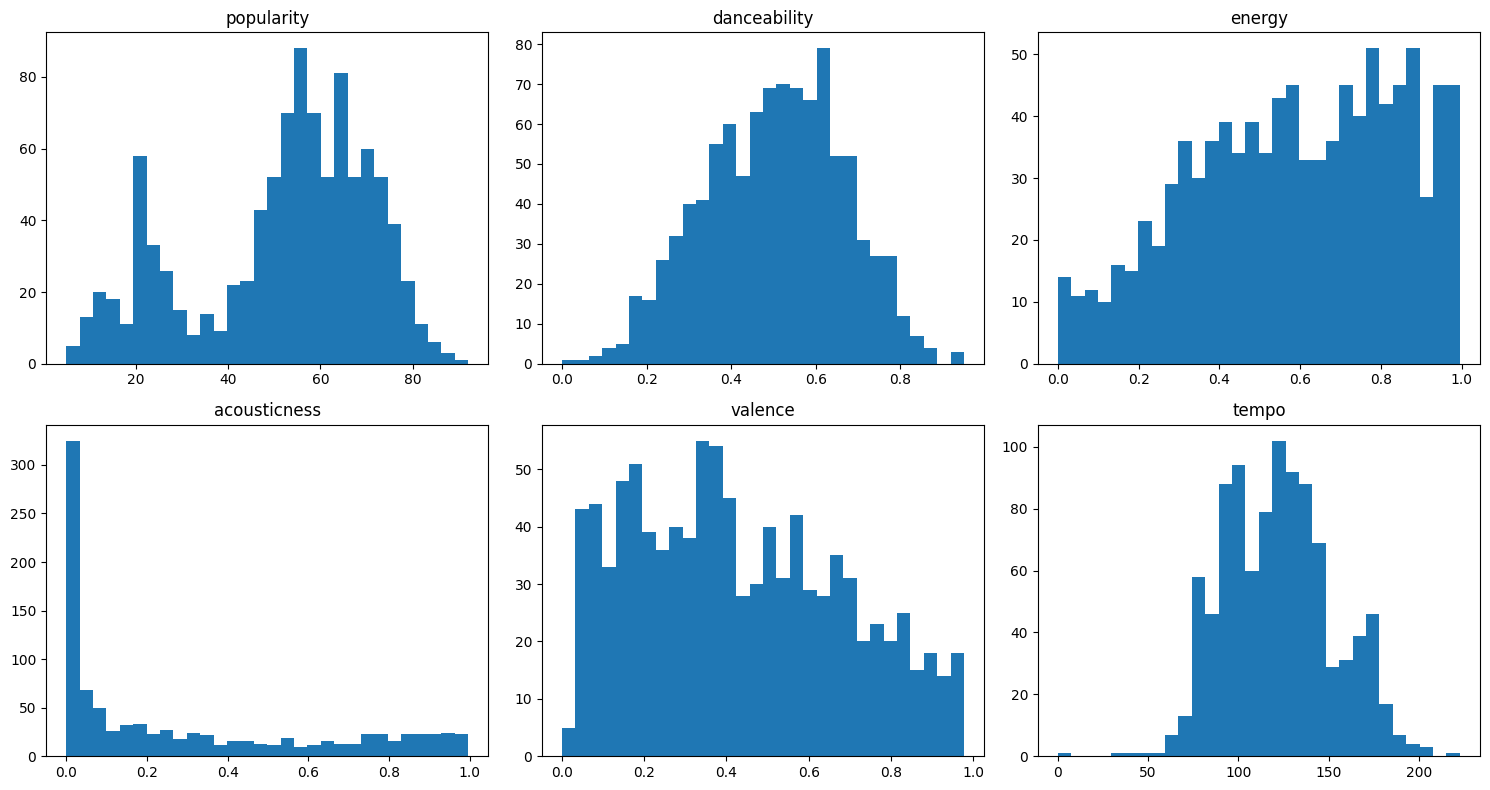

In [10]:
plot_cols = ['popularity', 'danceability', 'energy', 'acousticness', 'valence', 'tempo']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

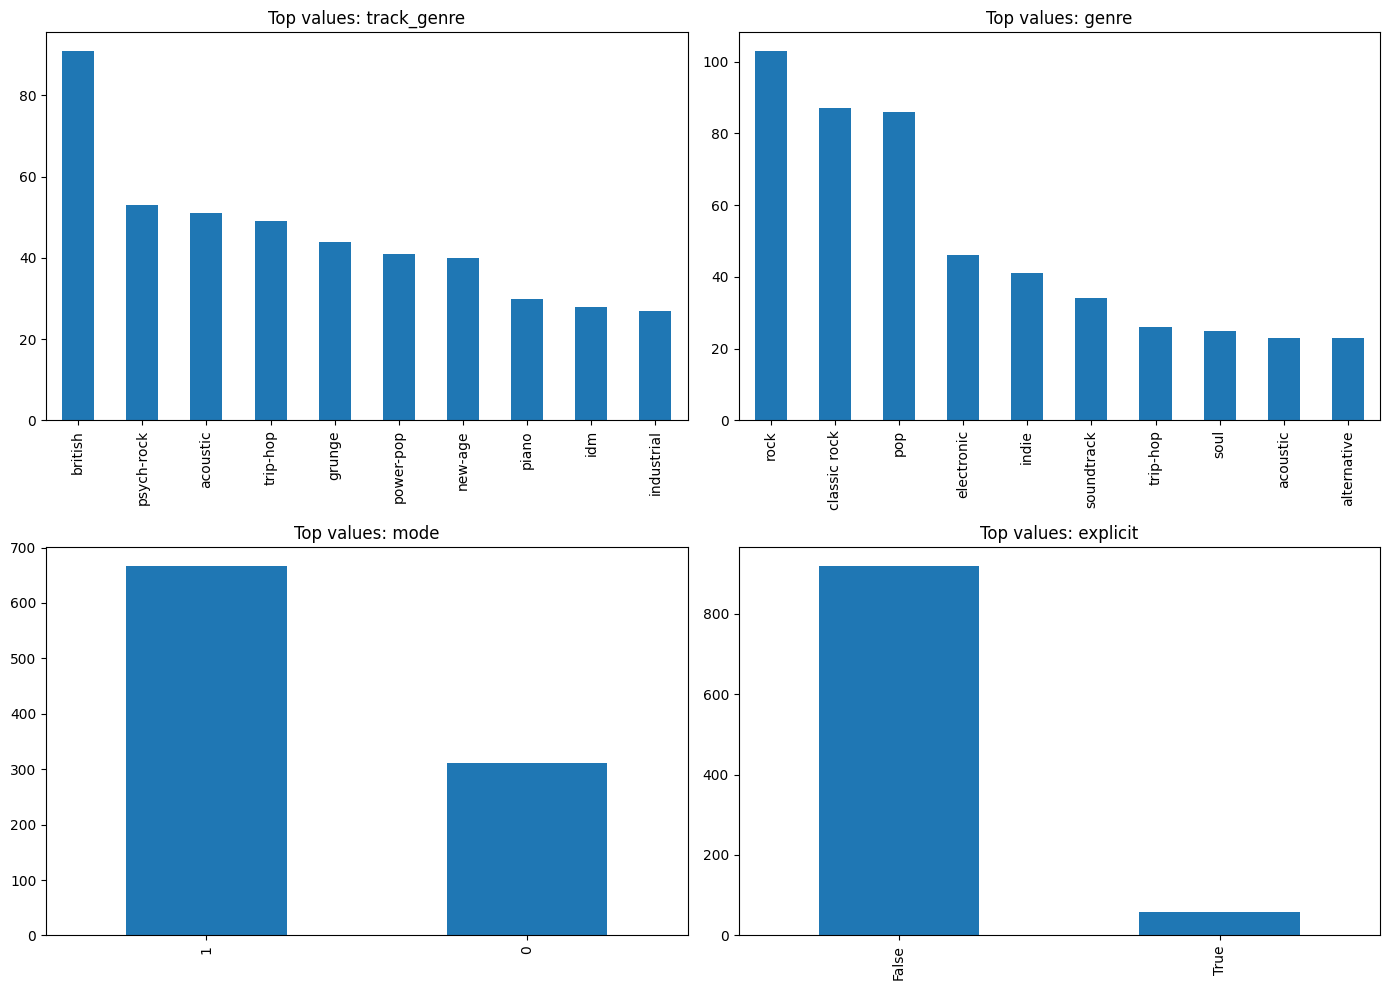

In [11]:
cat_cols = ['track_genre', 'genre', 'mode', 'explicit']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    top_vals = df[col].value_counts(dropna=False).head(10)
    top_vals.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Top values: {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

5) relationship exploration

In [12]:
corr_cols = [
    'popularity', 'danceability', 'energy', 'acousticness',
    'valence', 'tempo', 'arousal_tags', 'valence_tags', 'dominance_tags'
]

pair_rows = []
for feature_1, feature_2 in combinations(corr_cols, 2):
    pair_df = df[[feature_1, feature_2]].dropna()
    corr_value = pair_df[feature_1].corr(pair_df[feature_2])
    pair_rows.append({
        'feature_1': feature_1,
        'feature_2': feature_2,
        'corr': corr_value,
        'abs_corr': abs(corr_value)
    })

pair_corr = pd.DataFrame(pair_rows).sort_values('abs_corr', ascending=False).reset_index(drop=True)
pair_corr.head(10)

,feature_1,feature_2,corr,abs_corr
0,valence_tags,dominance_tags,0.887326,0.887326
1,energy,acousticness,-0.759662,0.759662
2,arousal_tags,dominance_tags,0.571619,0.571619
3,arousal_tags,valence_tags,0.542894,0.542894
4,danceability,valence,0.534370,0.534370
5,energy,valence,0.336298,0.336298
6,energy,arousal_tags,0.332926,0.332926
7,valence,dominance_tags,0.245056,0.245056
8,acousticness,arousal_tags,-0.244978,0.244978
9,valence,valence_tags,0.239172,0.239172


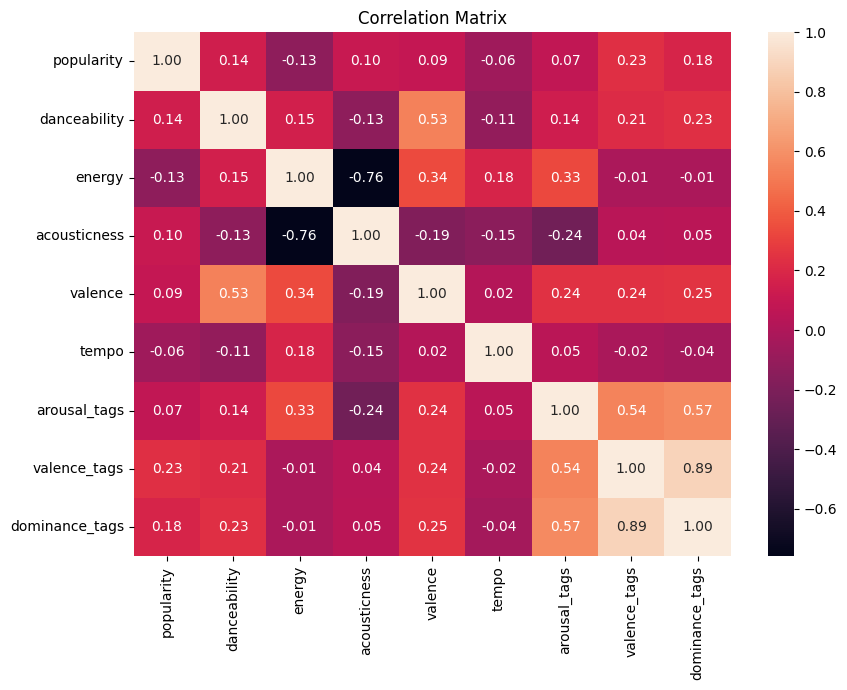

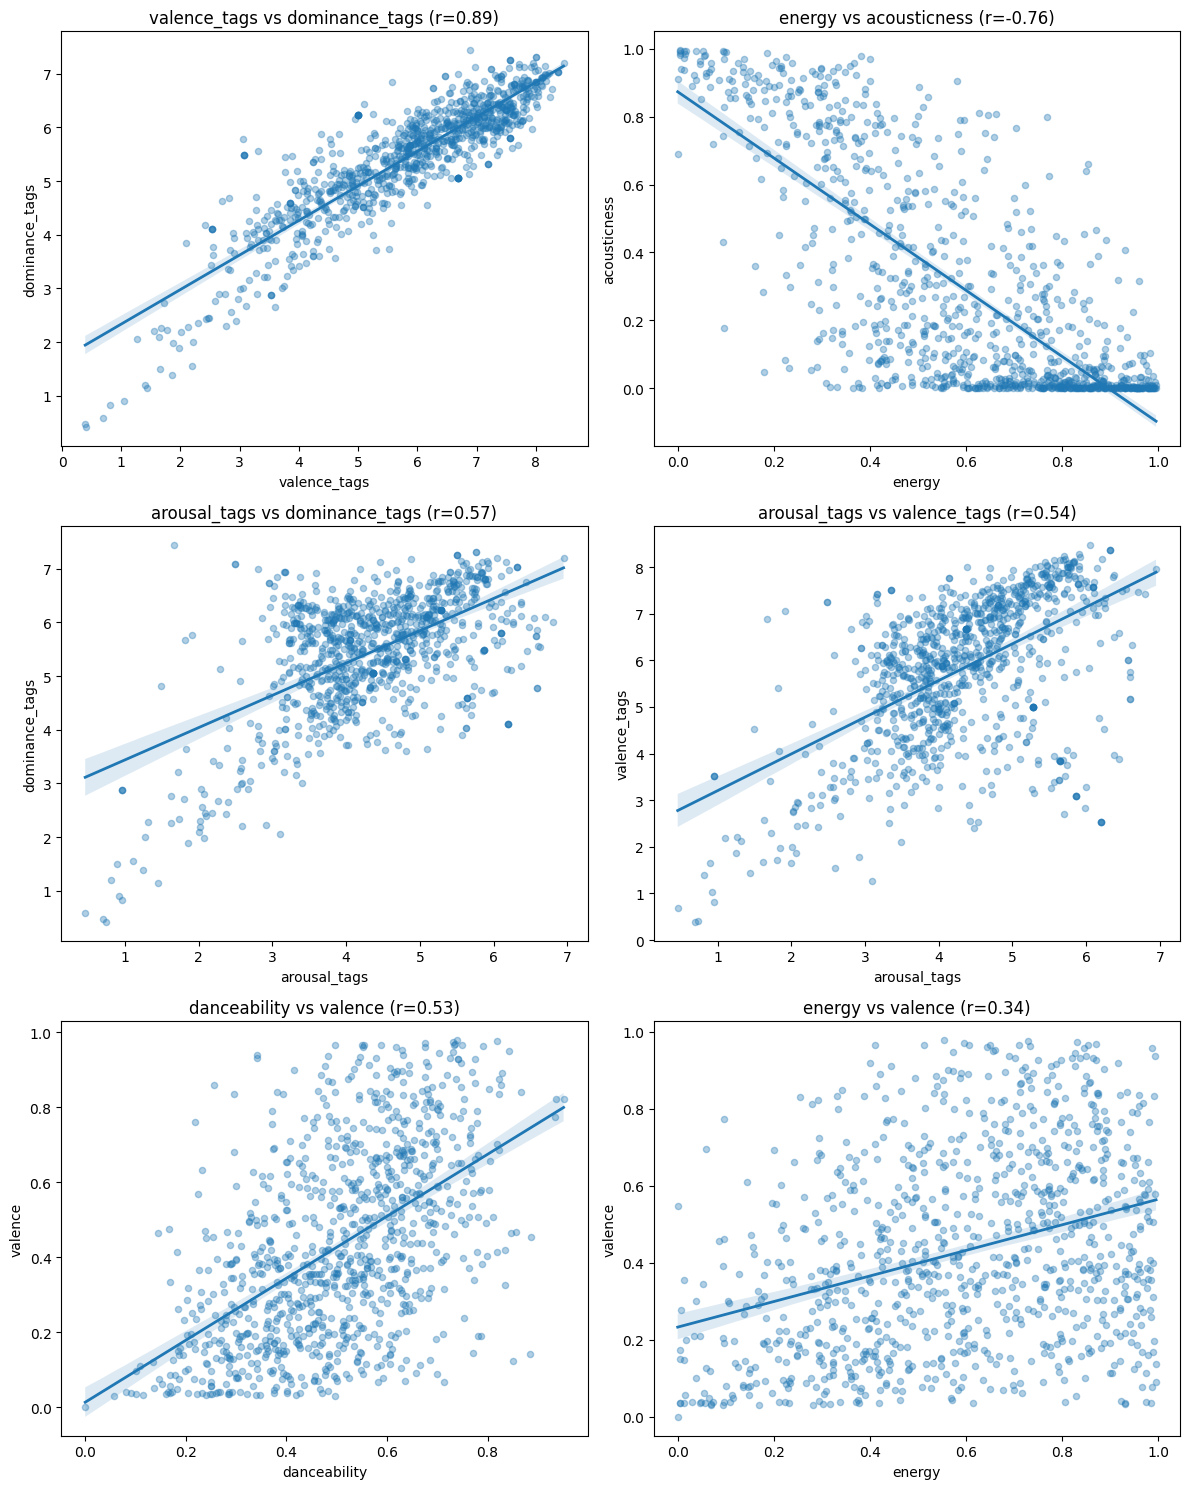

In [ ]:
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# only visualize pairs with stronger absolute correlation first.
plot_pairs = pair_corr[pair_corr['abs_corr'] >= 0.30].head(6).copy()
if plot_pairs.empty:
    plot_pairs = pair_corr.head(4).copy()

n_plots = len(plot_pairs)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
if n_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, (_, row) in enumerate(plot_pairs.iterrows()):
    ax = axes[i]
    sns.regplot(
        data=df,
        x=row['feature_1'],
        y=row['feature_2'],
        scatter_kws={'alpha': 0.35, 's': 20},
        line_kws={'linewidth': 2},
        ax=ax
    )
    ax.set_title(f"{row['feature_1']} vs {row['feature_2']} (r={row['corr']:.2f})")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

6) outlier snapshot with boxplots

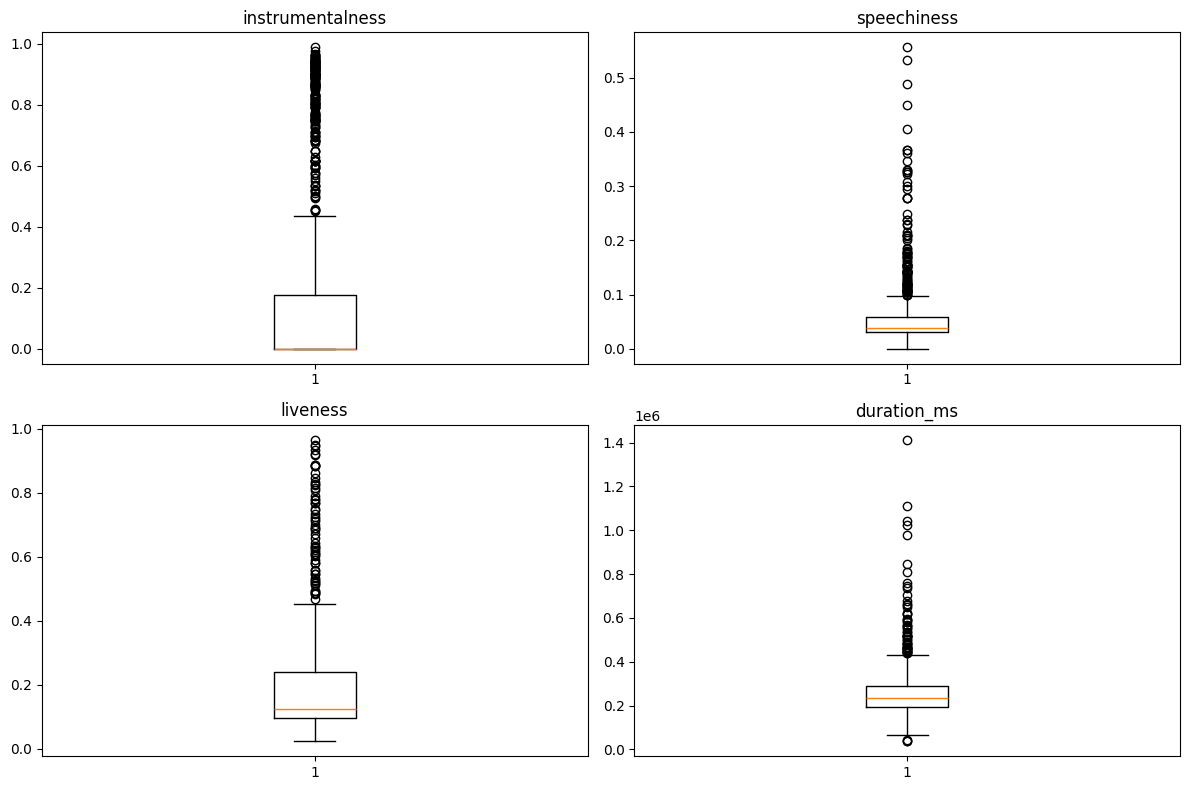

In [14]:
iqr_rows = []
for col in numeric_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = int(((s < lower) | (s > upper)).sum())
    iqr_rows.append({
        'feature': col,
        'outlier_count': outlier_count,
        'outlier_pct': round(outlier_count / len(s) * 100, 2)
    })

outlier_summary = pd.DataFrame(iqr_rows).sort_values('outlier_pct', ascending=False).reset_index(drop=True)
outlier_summary

outlier_plot_cols = outlier_summary[outlier_summary['outlier_pct'] > 0].head(4)['feature'].tolist()
if not outlier_plot_cols:
    outlier_plot_cols = outlier_summary.head(4)['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_plot_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

7) frequency view of most common artists

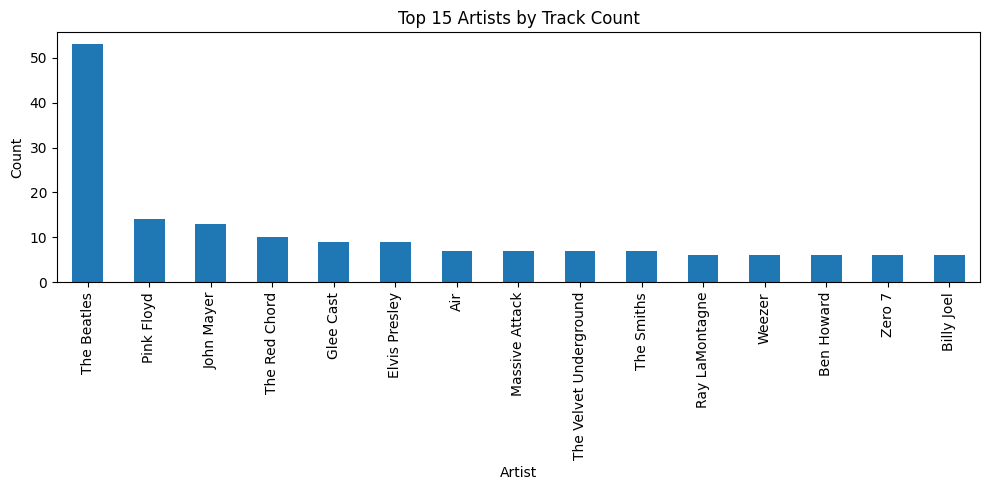

In [15]:
top_artists = df['artist'].value_counts().head(15)

plt.figure(figsize=(10, 5))
top_artists.plot(kind='bar')
plt.title('Top 15 Artists by Track Count')
plt.xlabel('Artist')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

emotional relationships

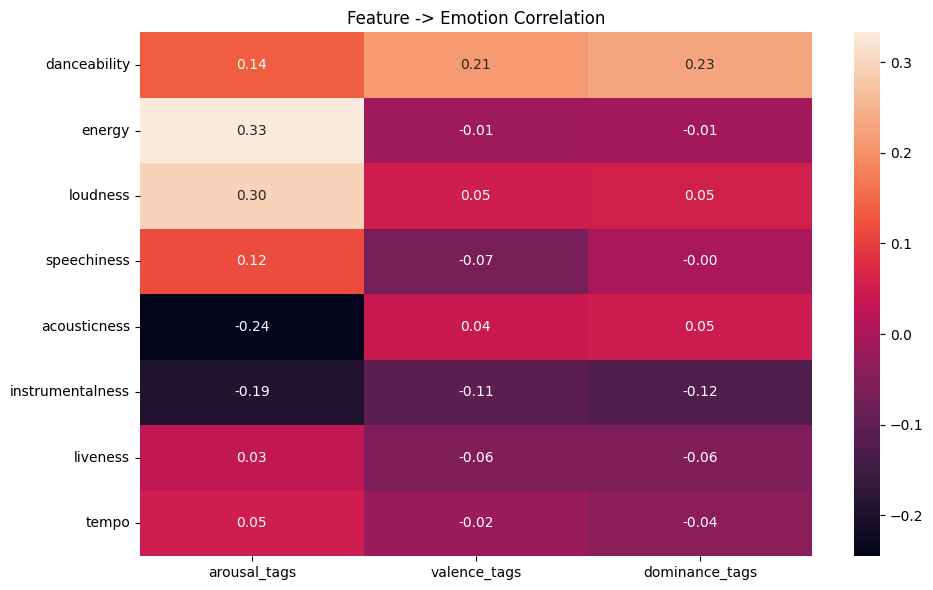

In [16]:
emotion_targets = ['arousal_tags', 'valence_tags', 'dominance_tags']

feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'tempo'
]

emotion_corr = df[feature_cols + emotion_targets].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(emotion_corr.loc[feature_cols, emotion_targets], annot=True, fmt='.2f')
plt.title('Feature -> Emotion Correlation')
plt.tight_layout()
plt.show()

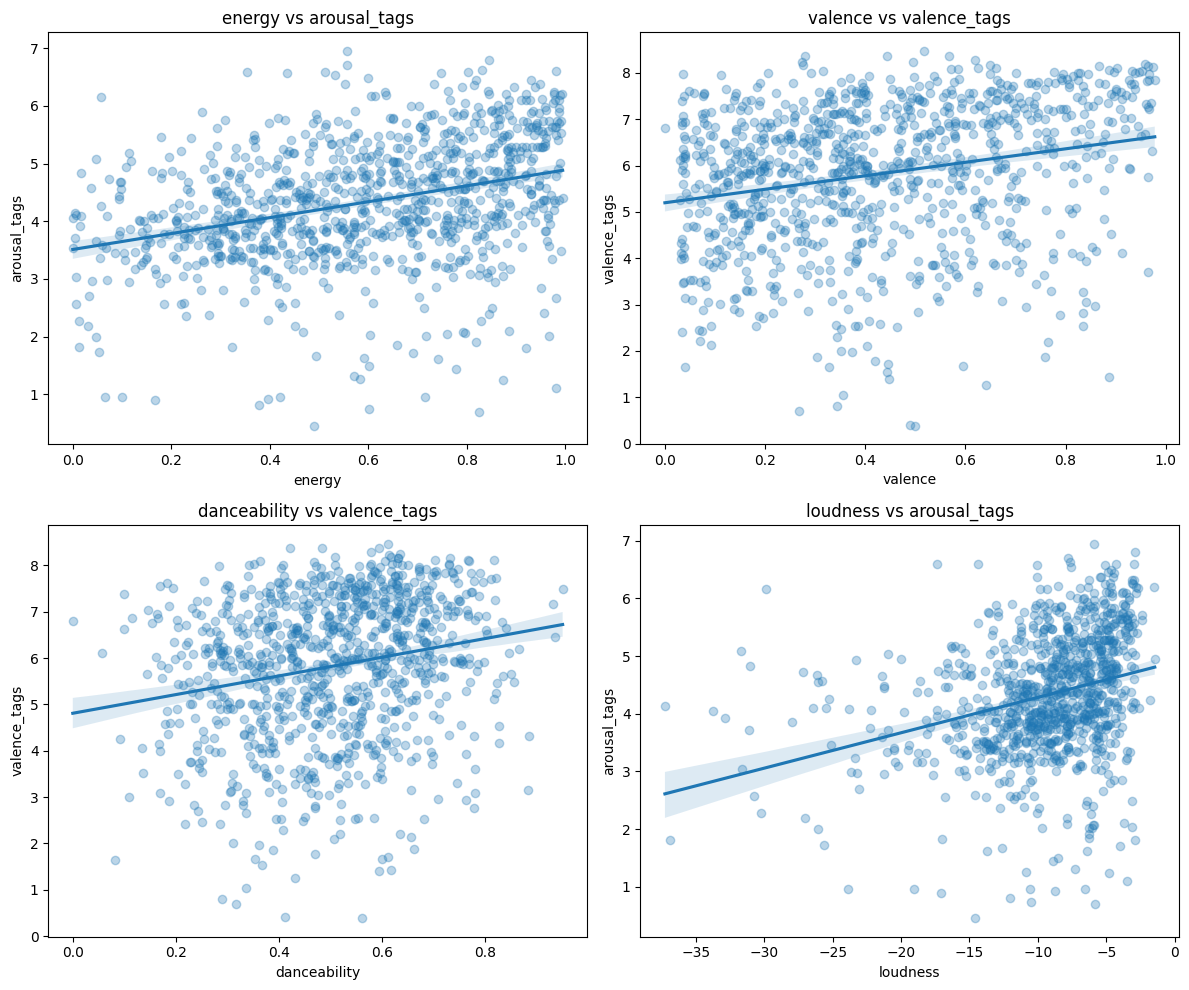

In [17]:
key_pairs = [
    ('energy', 'arousal_tags'),
    ('valence', 'valence_tags'),
    ('danceability', 'valence_tags'),
    ('loudness', 'arousal_tags')
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (x, y) in enumerate(key_pairs):
    sns.regplot(data=df, x=x, y=y, ax=axes[i],
                scatter_kws={'alpha': 0.3})
    axes[i].set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

8) EDA findings in paragraph form